In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = r"D:\do an\TPC_MachineLearning\data\tpc_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print(f"Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# ==========================================================
# Dataset Shape
# ==========================================================

print(f"Number of samples : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of samples : 27
Number of columns : 6


In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Run               27 non-null     int64  
 1   EtOH (%)          27 non-null     int64  
 2   Ratio (mL/g)      27 non-null     int64  
 3   Temperature (°C)  27 non-null     int64  
 4   Time (min)        27 non-null     int64  
 5   TPC (mg GAE/g)    27 non-null     float64
dtypes: float64(1), int64(5)
memory usage: 1.4 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Run,27.00,14.00,7.94,1.00,7.50,14.00,20.50,27.00
EtOH (%),27.00,75.00,10.19,60.00,75.00,75.00,75.00,90.00
Ratio (mL/g),27.00,20.00,2.72,16.00,20.00,20.00,20.00,24.00
Temperature (°C),27.00,60.00,10.19,45.00,60.00,60.00,60.00,75.00
Time (min),27.00,105.00,30.57,60.00,105.00,105.00,105.00,150.00
TPC (mg GAE/g),27.00,40.20,2.30,36.50,38.55,39.70,41.50,45.30


In [6]:
# ==========================================================
# Feature and Target
# ==========================================================

X = df.drop(columns=["Run", "TPC (mg GAE/g)"])

y = df["TPC (mg GAE/g)"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (27, 4)
Target Shape  : (27,)


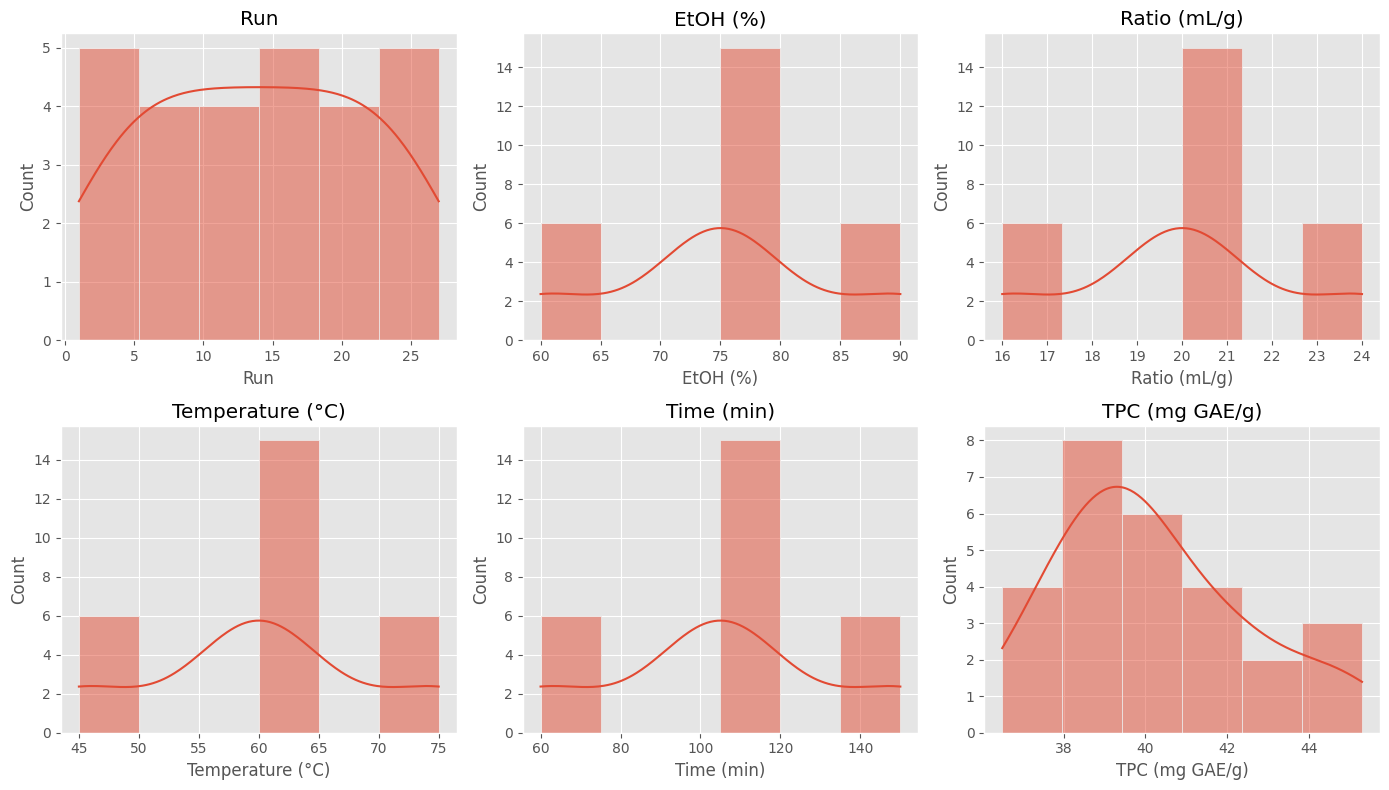

In [7]:
fig, axes = plt.subplots(2,3, figsize=(14,8))

columns = df.columns

for ax,col in zip(axes.flatten(), columns):

    sns.histplot(df[col], kde=True, ax=ax)

    ax.set_title(col)

plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix')

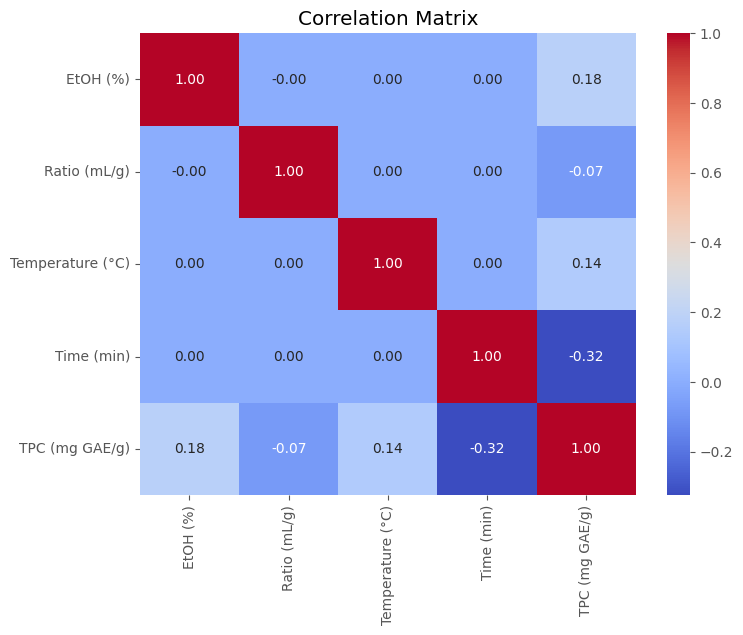

In [8]:
plt.figure(figsize=(8,6))

corr = df.drop(columns=["Run"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

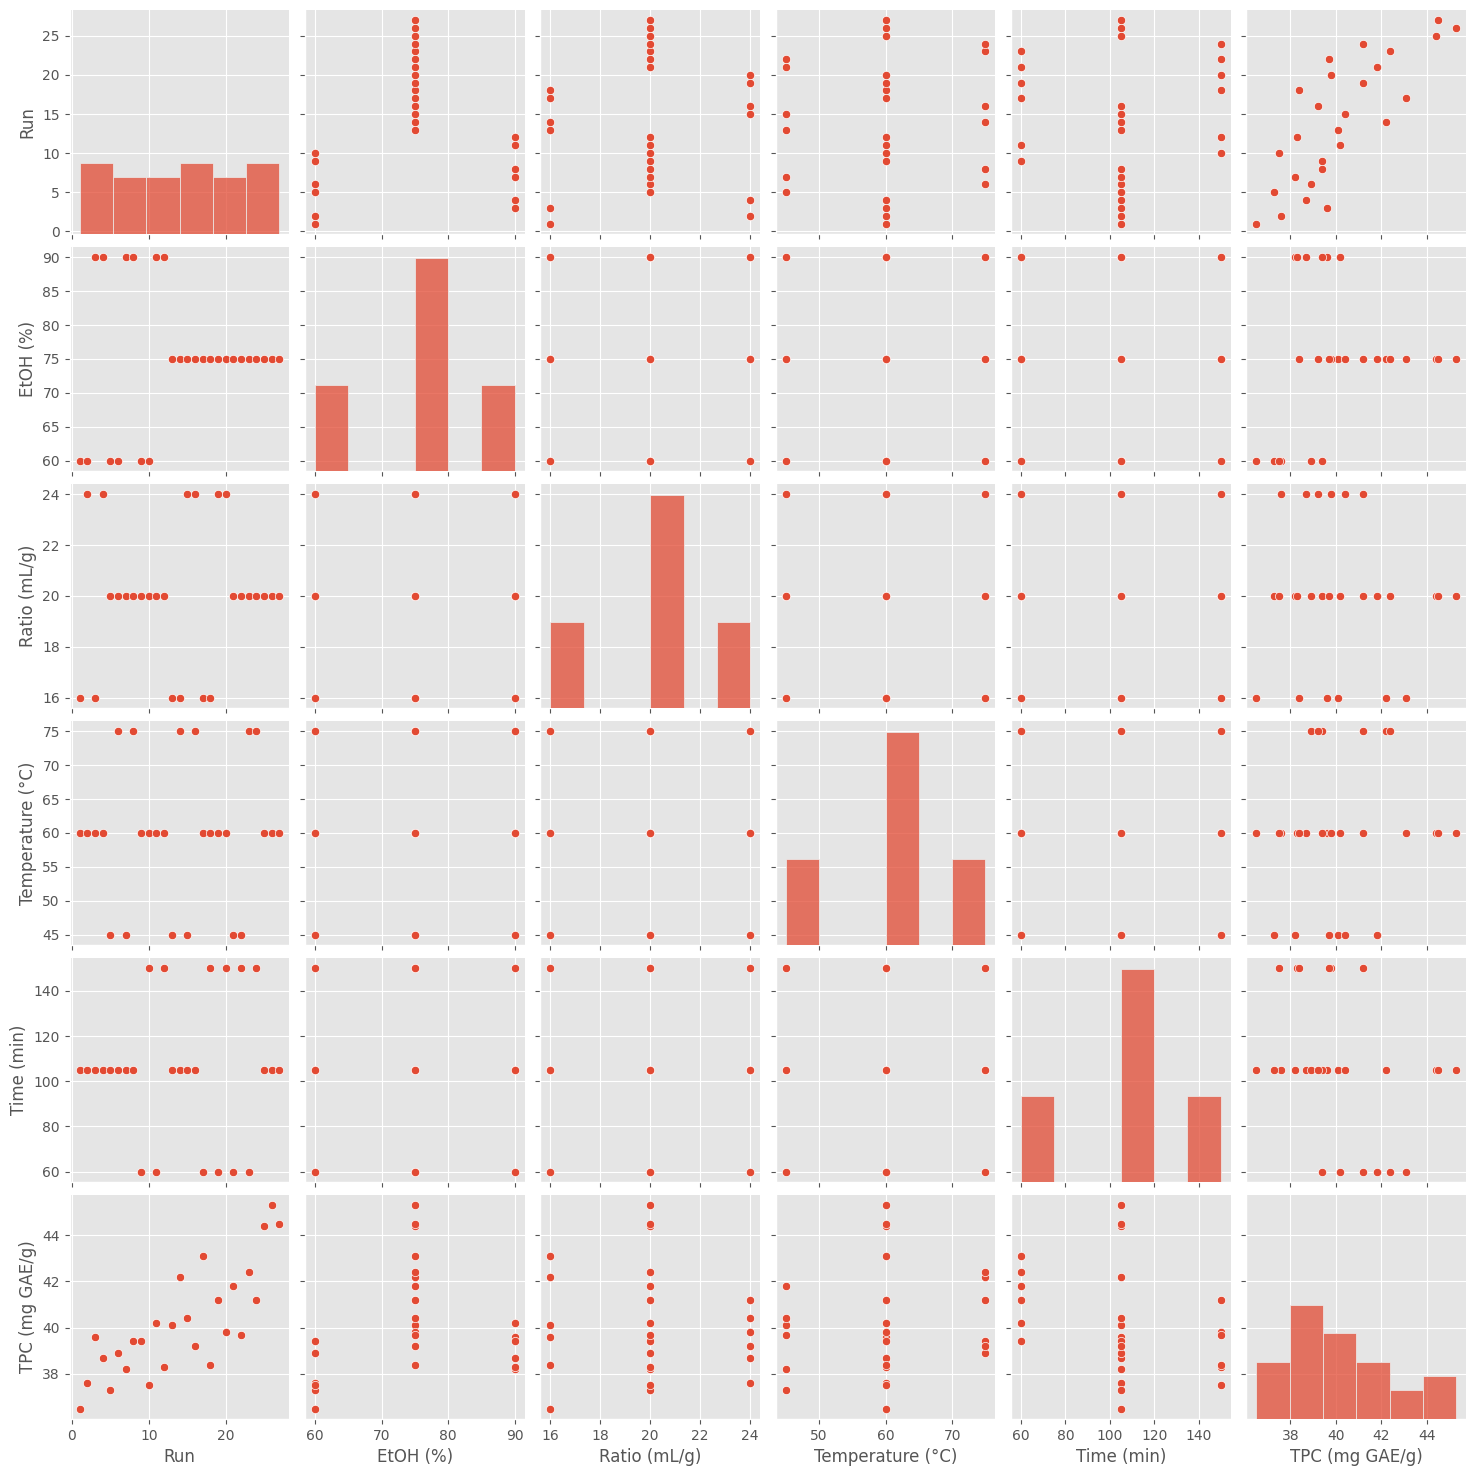

In [9]:
sns.pairplot(
    df,
    diag_kind="hist"
)

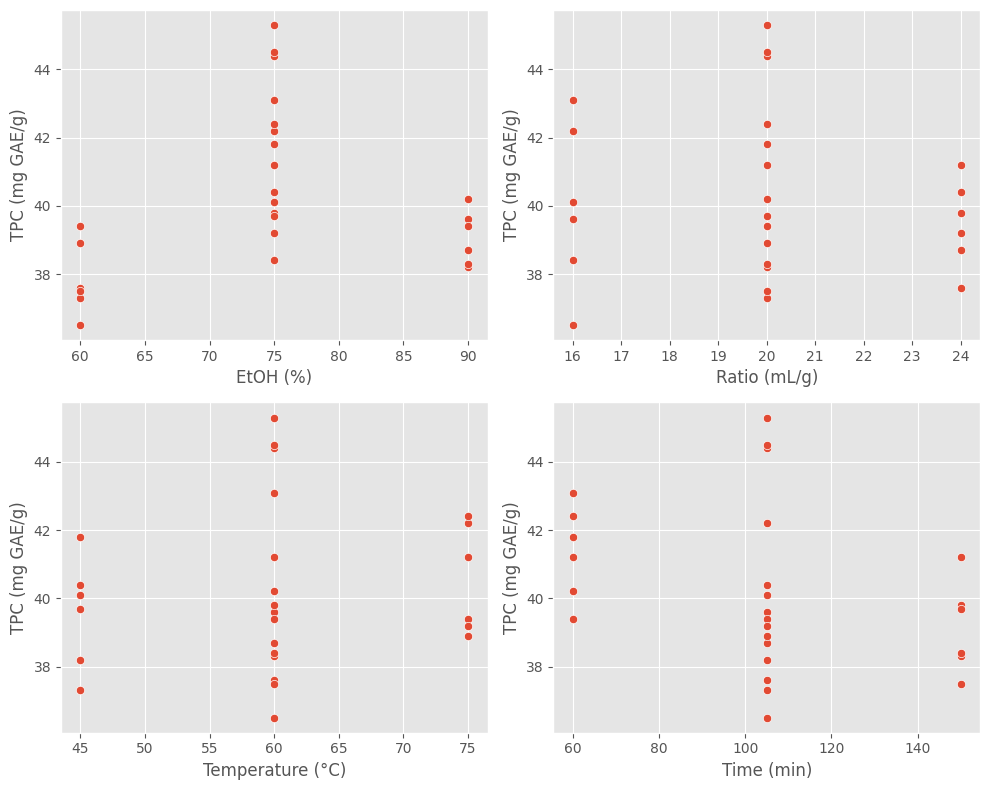

In [10]:
features = ["EtOH (%)","Ratio (mL/g)","Temperature (°C)","Time (min)"]

fig, axes = plt.subplots(2,2, figsize=(10,8))

for ax,col in zip(axes.flatten(),features):

    sns.scatterplot(
        data=df,
        x=col,
        y="TPC (mg GAE/g)",
        ax=ax
    )

plt.tight_layout()

In [11]:
from sklearn.preprocessing import StandardScaler
import joblib
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,EtOH (%),Ratio (mL/g),Temperature (°C),Time (min)
0,-1.50,-1.50,0.00,0.00
1,-1.50,1.50,0.00,0.00
2,1.50,-1.50,0.00,0.00
3,1.50,1.50,0.00,0.00
4,-1.50,0.00,-1.50,0.00


In [13]:
joblib.dump(
    scaler,
    "scaler.pkl"
)
X_scaled.to_csv(
    "X_scaled.csv",
    index=False
)

y.to_csv(
    "y.csv",
    index=False
)

In [14]:
X = pd.read_csv("X_scaled.csv")
y = pd.read_csv("y.csv").squeeze()

In [15]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

## 5. Random Forest
### 5.1 Hyperparameter Search

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search with LOOCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=loo,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Best Parameters for Random Forest:", grid_rf.best_params_)
rf_best = grid_rf.best_estimator_

Fitting 27 folds for each of 48 candidates, totalling 1296 fits
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 5.2 Training & Evaluation (LOOCV Predictions)
Chúng ta sẽ sử dụng phương thức `cross_val_predict` để lấy các giá trị dự đoán từ LOOCV nhằm đánh giá độ chính xác thực tế của mô hình.

In [17]:
from sklearn.model_selection import cross_val_predict

# Generate predictions using LOOCV
y_pred_rf = cross_val_predict(rf_best, X, y, cv=loo)

# Evaluation Metrics
mse_rf = mean_squared_error(y, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y, y_pred_rf)
r2_rf = r2_score(y, y_pred_rf)

print(f"--- Random Forest Evaluation ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

--- Random Forest Evaluation ---
MAE:  1.0050
MSE:  1.9948
RMSE: 1.4124
R2:   0.6097


### 5.3 Visualization (Actual vs Predicted)

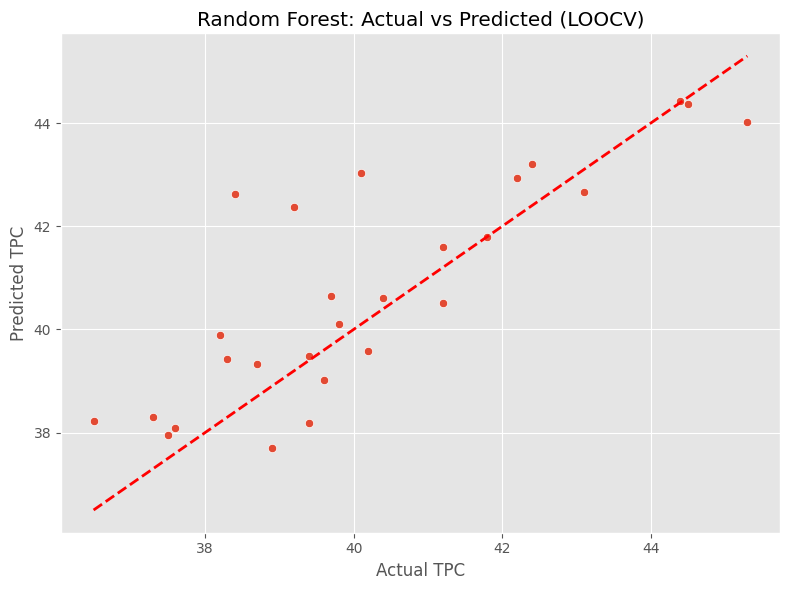

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_rf)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual TPC")
plt.ylabel("Predicted TPC")
plt.title("Random Forest: Actual vs Predicted (LOOCV)")
plt.tight_layout()
plt.show()

### 5.4 Feature Importance (Random Forest)

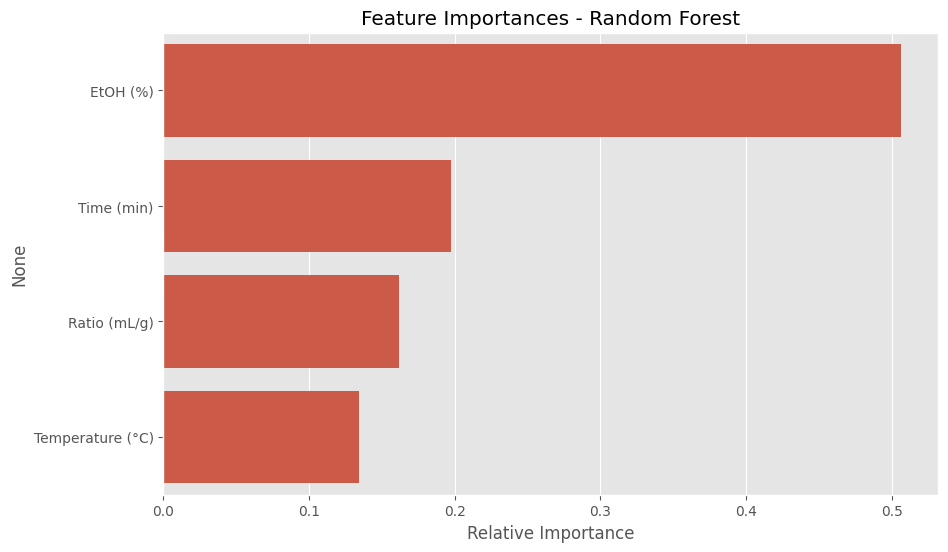

In [19]:
importances_rf = rf_best.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Random Forest")
sns.barplot(x=importances_rf[indices_rf], y=X.columns[indices_rf])
plt.xlabel("Relative Importance")
plt.show()

## 6. XGBoost
### 6.1 Hyperparameter Search

In [20]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=loo,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X, y)

print("Best Parameters for XGBoost:", grid_xgb.best_params_)
xgb_best = grid_xgb.best_estimator_

Fitting 27 folds for each of 54 candidates, totalling 1458 fits
Best Parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


### 6.2 Training & Evaluation (LOOCV)

In [21]:
y_pred_xgb = cross_val_predict(xgb_best, X, y, cv=loo)

mse_xgb = mean_squared_error(y, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y, y_pred_xgb)
r2_xgb = r2_score(y, y_pred_xgb)

print(f"--- XGBoost Evaluation ---")
print(f"MAE:  {mae_xgb:.4f}")
print(f"MSE:  {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2:   {r2_xgb:.4f}")

--- XGBoost Evaluation ---
MAE:  0.9056
MSE:  1.3807
RMSE: 1.1751
R2:   0.7298


### 6.3 & 6.4 Visualization and Feature Importance (XGBoost)

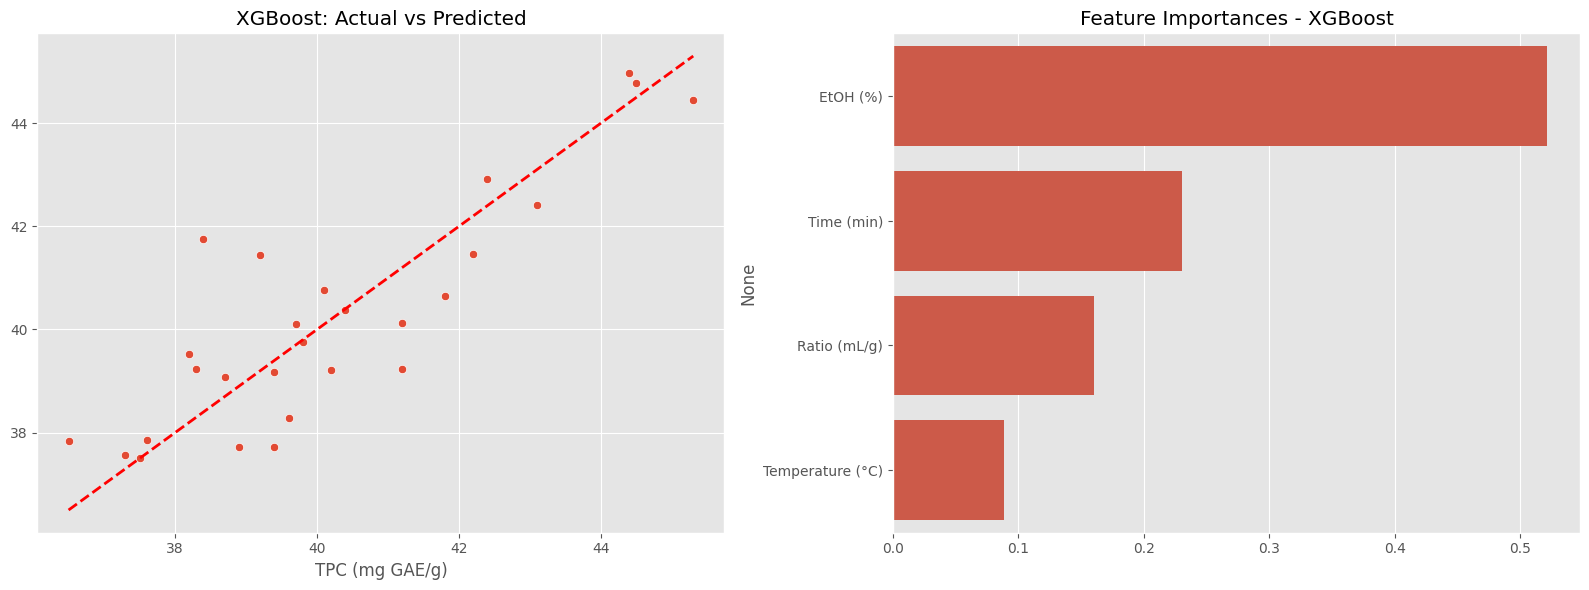

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y, y=y_pred_xgb, ax=ax[0])
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax[0].set_title("XGBoost: Actual vs Predicted")

importances_xgb = xgb_best.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]
sns.barplot(x=importances_xgb[indices_xgb], y=X.columns[indices_xgb], ax=ax[1])
ax[1].set_title("Feature Importances - XGBoost")

plt.tight_layout()
plt.show()

## 7. Response Surface Methodology (RSM)

RSM là mô hình đa thức bậc 2 truyền thống được sử dụng rộng rãi trong tối ưu hóa quy trình hóa học và thực phẩm.

### 7.1 Khởi tạo & Huấn luyện (LOOCV)

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
# Load original unscaled features (RSM works on raw features)
df_raw = pd.read_excel(DATA_PATH)
X_raw = df_raw.drop(columns=["Run", "TPC (mg GAE/g)"])
y_raw = df_raw["TPC (mg GAE/g)"]

# 2nd-order Polynomial RSM pipeline
rsm = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# Training R2 (full data)
rsm.fit(X_raw, y_raw)
r2_rsm_train = r2_score(y_raw, rsm.predict(X_raw))
print(f'Training R2 (full data): {r2_rsm_train:.4f}')

# LOOCV
loo_rsm = LeaveOneOut()
y_pred_rsm = cross_val_predict(rsm, X_raw, y_raw, cv=loo_rsm)
mse_rsm  = mean_squared_error(y_raw, y_pred_rsm)
rmse_rsm = np.sqrt(mse_rsm)
mae_rsm  = mean_absolute_error(y_raw, y_pred_rsm)
r2_rsm   = r2_score(y_raw, y_pred_rsm)
print(f'--- RSM (2nd-Order Polynomial) LOOCV ---')
print(f'MAE:  {mae_rsm:.4f}')
print(f'MSE:  {mse_rsm:.4f}')
print(f'RMSE: {rmse_rsm:.4f}')
print(f'R2:   {r2_rsm:.4f}')

Training R2 (full data): 0.9672
--- RSM (2nd-Order Polynomial) LOOCV ---
MAE:  0.7933
MSE:  0.9035
RMSE: 0.9505
R2:   0.8232


### 7.2 Visualization (Actual vs Predicted)

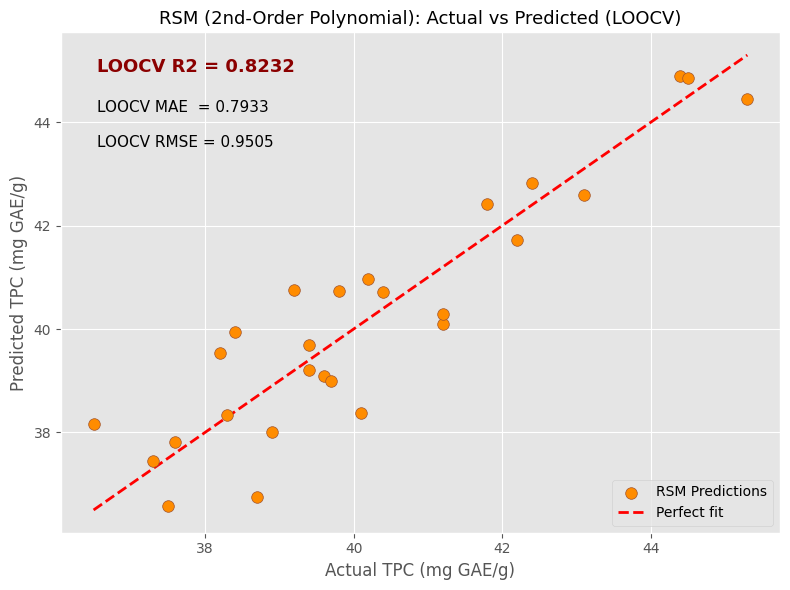

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(y_raw, y_pred_rsm, color='darkorange', edgecolors='sienna', s=70, zorder=5, label='RSM Predictions')
ax.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2, label='Perfect fit')
ax.text(0.05, 0.92, f'LOOCV R2 = {r2_rsm:.4f}', transform=ax.transAxes,
        fontsize=13, color='darkred', fontweight='bold')
ax.text(0.05, 0.84, f'LOOCV MAE  = {mae_rsm:.4f}', transform=ax.transAxes, fontsize=11)
ax.text(0.05, 0.77, f'LOOCV RMSE = {rmse_rsm:.4f}', transform=ax.transAxes, fontsize=11)
ax.set_xlabel('Actual TPC (mg GAE/g)', fontsize=12)
ax.set_ylabel('Predicted TPC (mg GAE/g)', fontsize=12)
ax.set_title('RSM (2nd-Order Polynomial): Actual vs Predicted (LOOCV)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Gaussian Process Regression (GPR)
GPR (hay còn gọi là **Kriging**) là phương pháp phi tham số, đặc biệt phù hợp với dữ liệu nhỏ, có cấu trúc như thiết kế RSM.

### 8.1 Khởi tạo & Huấn luyện (LOOCV)

In [25]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.pipeline import Pipeline

# Best kernel from hyperparameter search: RBF with alpha=0.05
kernel_gpr = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

gpr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GaussianProcessRegressor(
        kernel=kernel_gpr,
        alpha=0.05,
        n_restarts_optimizer=10,
        random_state=42
    ))
])

# LOOCV predictions
loo_gpr = LeaveOneOut()
y_pred_gpr = cross_val_predict(gpr, X_raw, y_raw, cv=loo_gpr)

# Metrics
mse_gpr  = mean_squared_error(y_raw, y_pred_gpr)
rmse_gpr = np.sqrt(mse_gpr)
mae_gpr  = mean_absolute_error(y_raw, y_pred_gpr)
r2_gpr   = r2_score(y_raw, y_pred_gpr)

print(f"--- Gaussian Process Regression (LOOCV) ---")
print(f"MAE:  {mae_gpr:.4f}")
print(f"MSE:  {mse_gpr:.4f}")
print(f"RMSE: {rmse_gpr:.4f}")
print(f"R2:   {r2_gpr:.4f}")

--- Gaussian Process Regression (LOOCV) ---
MAE:  0.5581
MSE:  0.4369
RMSE: 0.6610
R2:   0.9145


### 8.2 Visualization (Actual vs Predicted)

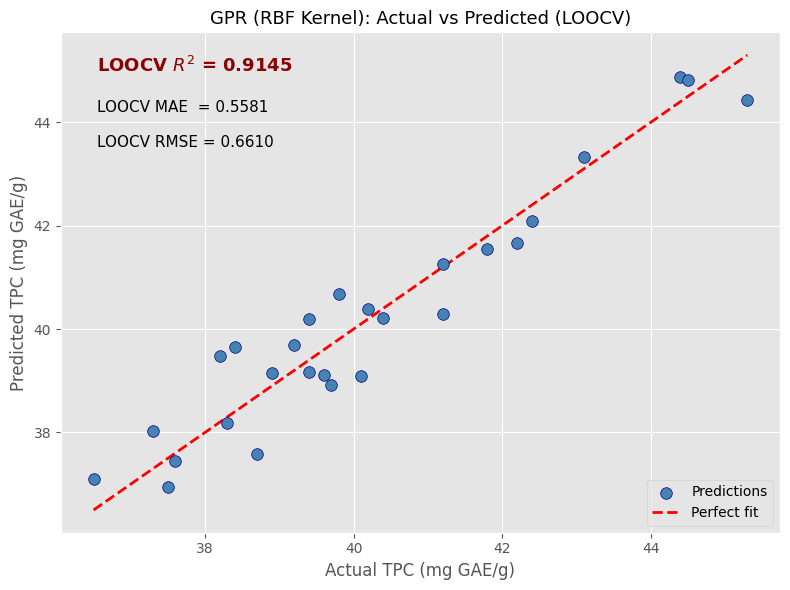

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.scatter(y_raw, y_pred_gpr, color='steelblue', edgecolors='navy', s=70, zorder=5, label='Predictions')
ax.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2, label='Perfect fit')

# Annotate R2
ax.text(0.05, 0.92, f'LOOCV $R^2$ = {r2_gpr:.4f}', transform=ax.transAxes,
        fontsize=13, color='darkred', fontweight='bold')
ax.text(0.05, 0.84, f'LOOCV MAE  = {mae_gpr:.4f}', transform=ax.transAxes, fontsize=11)
ax.text(0.05, 0.77, f'LOOCV RMSE = {rmse_gpr:.4f}', transform=ax.transAxes, fontsize=11)

ax.set_xlabel('Actual TPC (mg GAE/g)', fontsize=12)
ax.set_ylabel('Predicted TPC (mg GAE/g)', fontsize=12)
ax.set_title('GPR (RBF Kernel): Actual vs Predicted (LOOCV)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 9. So sánh toàn bộ mô hình
So sánh các chỉ số MAE, RMSE và R² giữa **Random Forest**, **XGBoost** và **GPR (Gaussian Process Regression)**.

        Model  LOOCV MAE  LOOCV MSE  LOOCV RMSE  LOOCV R2
Random Forest       1.00       1.99        1.41      0.61
      XGBoost       0.91       1.38        1.18      0.73
  RSM (Poly2)       0.79       0.90        0.95      0.82
    GPR (RBF)       0.56       0.44        0.66      0.91


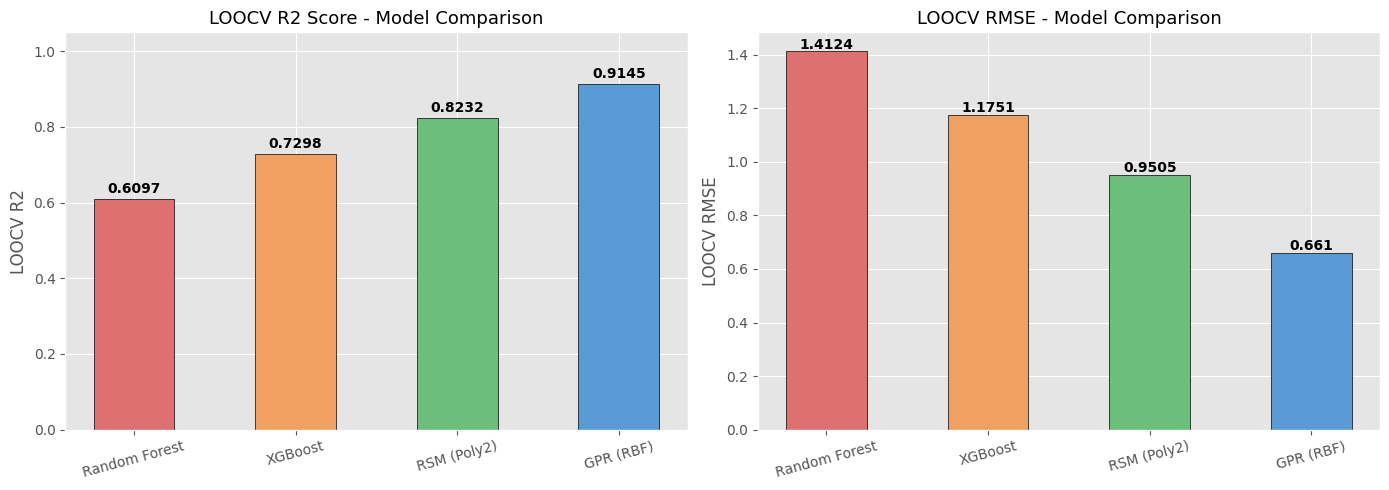

In [27]:
# Build comparison table
comparison = pd.DataFrame({
    "Model":         ['Random Forest', 'XGBoost', 'RSM (Poly2)', 'GPR (RBF)'],
    "LOOCV MAE":     [round(mae_rf, 4),  round(mae_xgb, 4),  round(mae_rsm,4),  round(mae_gpr, 4)],
    "LOOCV MSE":     [round(mse_rf, 4),  round(mse_xgb, 4),  round(mse_rsm,4),  round(mse_gpr, 4)],
    "LOOCV RMSE":    [round(rmse_rf, 4), round(rmse_xgb, 4), round(rmse_rsm,4), round(rmse_gpr, 4)],
    "LOOCV R2":      [round(r2_rf, 4),   round(r2_xgb, 4),   round(r2_rsm,4),   round(r2_gpr, 4)],
})

print(comparison.to_string(index=False))
# Colors: RF=red, XGB=orange, RSM=green, GPR=blue
colors = ['#E07070', '#F0A060', '#6BBF7B', '#5B9BD5']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# R2 bar chart
bars = axes[0].bar(comparison['Model'], comparison['LOOCV R2'],
                   color=colors, edgecolor='black', width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('LOOCV R2', fontsize=12)
axes[0].set_title('LOOCV R2 Score - Model Comparison', fontsize=13)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, comparison['LOOCV R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.015,
                 str(v), ha='center', fontsize=10, fontweight='bold')
# RMSE bar chart
bars2 = axes[1].bar(comparison['Model'], comparison['LOOCV RMSE'],
                    color=colors, edgecolor='black', width=0.5)
axes[1].set_ylabel('LOOCV RMSE', fontsize=12)
axes[1].set_title('LOOCV RMSE - Model Comparison', fontsize=13)
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, comparison['LOOCV RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Lưu mô hình tốt nhất
GPR cho kết quả LOOCV R² cao nhất (**0.9145**), do đó chúng ta sẽ lưu mô hình này.

In [28]:
import os
# Fit GPR on full dataset
gpr.fit(X_raw, y_raw)
# Save GPR model
model_save_path = os.path.join(os.path.dirname(DATA_PATH), '..', 'models', 'best_gpr_model.pkl')
model_save_path = os.path.normpath(model_save_path)
joblib.dump(gpr, model_save_path)
# Also save RSM model
rsm_save_path = os.path.join(os.path.dirname(DATA_PATH), '..', 'models', 'rsm_model.pkl')
rsm_save_path = os.path.normpath(rsm_save_path)
joblib.dump(rsm, rsm_save_path)
print(f'GPR model saved to: {model_save_path}')
print(f'RSM model saved to: {rsm_save_path}')
print(f'GPR LOOCV R2 = {r2_gpr:.4f}  (Best model)')
print(f'RSM LOOCV R2 = {r2_rsm:.4f}')

GPR model saved to: D:\do an\TPC_MachineLearning\models\best_gpr_model.pkl
RSM model saved to: D:\do an\TPC_MachineLearning\models\rsm_model.pkl
GPR LOOCV R2 = 0.9145  (Best model)
RSM LOOCV R2 = 0.8232


## 11. Tối ưu hóa điều kiện trích ly bằng RSM

Cell này tìm cực đại của phương trình RSM bậc hai **trong đúng miền thí nghiệm**. Kết quả là điều kiện đề xuất để làm thí nghiệm xác nhận, không phải kết quả GPR.

In [29]:
# ==========================================================
# RSM optimization within the experimental domain
# ==========================================================
import itertools

feature_names = ["EtOH (%)", "Ratio (mL/g)", "Temperature (°C)", "Time (min)"]
center = np.array([75.0, 20.0, 60.0, 105.0])
half_range = np.array([15.0, 4.0, 15.0, 45.0])

# Convert real experimental variables to CCD coded variables (-1, 0, +1).
X_coded = (X_raw[feature_names].to_numpy(dtype=float) - center) / half_range

# Full second-order RSM: intercept + linear + quadratic + two-factor interactions.
n_samples = len(X_coded)
interaction_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
Z = np.column_stack([
    np.ones(n_samples),
    X_coded,
    X_coded ** 2,
    *[X_coded[:, i] * X_coded[:, j] for i, j in interaction_pairs]
])
beta = np.linalg.lstsq(Z, y_raw.to_numpy(dtype=float), rcond=None)[0]

# Write the quadratic model as y = beta_0 + l'x + x'Qx.
linear_coef = beta[1:5]
Q = np.diag(beta[5:9])
for k, (i, j) in enumerate(interaction_pairs):
    Q[i, j] = Q[j, i] = beta[9 + k] / 2

def rsm_predict_coded(x):
    return beta[0] + linear_coef @ x + x @ Q @ x

# A quadratic can have a maximum on an interior point, edge, face, or corner.
# Enumerate every boundary combination and solve stationary points on free dimensions.
candidates = []
for state in itertools.product([-1.0, 0.0, 1.0], repeat=4):
    x = np.asarray(state, dtype=float)
    active = [i for i, value in enumerate(state) if value != 0.0]
    free = [i for i, value in enumerate(state) if value == 0.0]

    if free:
        Q_ff = Q[np.ix_(free, free)]
        rhs = -linear_coef[free]
        if active:
            rhs -= 2 * Q[np.ix_(free, active)] @ x[active]
        try:
            x[free] = np.linalg.solve(2 * Q_ff, rhs)
        except np.linalg.LinAlgError:
            continue

    if np.all(x >= -1 - 1e-8) and np.all(x <= 1 + 1e-8):
        candidates.append((rsm_predict_coded(x), x))

best_tpc_rsm, best_x_coded = max(candidates, key=lambda item: item[0])
best_x_real = center + best_x_coded * half_range

rsm_optimum = pd.DataFrame([best_x_real], columns=feature_names)
rsm_optimum["Predicted TPC (mg GAE/g)"] = best_tpc_rsm

print("=== RSM PREDICTED OPTIMUM (within the experimental range) ===")
display(rsm_optimum.round(3))
print("\nCoded condition (-1 to +1):", np.round(best_x_coded, 4))
print("This is an RSM optimum. Validate it experimentally with at least 3 replicates.")

=== RSM PREDICTED OPTIMUM (within the experimental range) ===


,EtOH (%),Ratio (mL/g),Temperature (°C),Time (min),Predicted TPC (mg GAE/g)
0,76.15,19.41,62.03,88.47,45.01



Coded condition (-1 to +1): [ 0.0768 -0.1468  0.1356 -0.3673]
This is an RSM optimum. Validate it experimentally with at least 3 replicates.


### 11.1 So sánh với giá trị cao nhất đã quan sát

Giá trị cao nhất quan sát được là kết quả thực nghiệm; giá trị ở trên là giá trị do RSM dự đoán. Cả hai cần được báo cáo riêng.

In [30]:
best_observed_idx = y_raw.idxmax()
best_observed = df_raw.loc[best_observed_idx, feature_names + ["TPC (mg GAE/g)"]].to_frame().T

print("=== HIGHEST OBSERVED EXPERIMENTAL TPC ===")
display(best_observed.round(3))

comparison_optimum = pd.DataFrame({
    "Result": ["RSM predicted optimum", "Highest observed experiment"],
    "TPC (mg GAE/g)": [best_tpc_rsm, y_raw.loc[best_observed_idx]],
})
display(comparison_optimum.round(3))

print("Recommended confirmation experiment (rounded):")
print(f"EtOH = {best_x_real[0]:.1f}%, Ratio = {best_x_real[1]:.1f} mL/g, "
      f"Temperature = {best_x_real[2]:.1f} °C, Time = {best_x_real[3]:.0f} min")

=== HIGHEST OBSERVED EXPERIMENTAL TPC ===


,EtOH (%),Ratio (mL/g),Temperature (°C),Time (min),TPC (mg GAE/g)
25,75.00,20.00,60.00,105.00,45.30


,Result,TPC (mg GAE/g)
0,RSM predicted optimum,45.01
1,Highest observed experiment,45.30


Recommended confirmation experiment (rounded):
EtOH = 76.2%, Ratio = 19.4 mL/g, Temperature = 62.0 °C, Time = 88 min
